In [1]:
import glob, os, pathlib, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['hatch.linewidth'] = 2.0
FONTSIZE = 28

SYSTEM_STYLE = {
    'ShuntServe': {'color': '#3498db', 'hatch': '/'},
    'HexGen':     {'color': '#1abc9c', 'hatch': '\\'},
    'AlpaServe':  {'color': '#e91e63', 'hatch': 'x'},
    'vLLM':       {'color': '#9b59b6', 'hatch': '+'},
}
SYSTEM_ORDER = ['ShuntServe', 'HexGen', 'AlpaServe', 'vLLM']
SYSTEM_NAME_MAP = {
    'shuntserve': 'ShuntServe',
    'hexgen': 'HexGen',
    'alpaserve': 'AlpaServe',
    'vllm': 'vLLM',
}

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
FIG_DIR = BASE_DIR  # current ./ dir
os.makedirs(FIG_DIR, exist_ok=True)


def plot_offline_throughput(model, t_start_min=0, t_end_min=5, show_title=False, source='csv'):
    """Plot measured system-level throughput for offline traces.

    source: 'csv'  — compute throughput from CSV traces over [t_start_min, t_end_min)
            'json' — use aggregated request_throughput from JSON benchmark results
    """
    model_dir = os.path.join(BASE_DIR, '..', model)
    model_safe = model.replace('-', '_')

    if source == 'json':
        json_dir = os.path.join(model_dir, 'json')
        json_files = sorted(glob.glob(os.path.join(json_dir, '*.json')))
        if not json_files:
            print(f'No JSON files found in {json_dir}')
            return

        results = {}
        for jp in json_files:
            # filename: offline_{system}.json
            stem = pathlib.Path(jp).stem.replace('offline_', '')
            sys_name = SYSTEM_NAME_MAP.get(stem)
            if sys_name is None:
                print(f'  Skipping unknown file: {os.path.basename(jp)}')
                continue
            with open(jp) as f:
                d = json.load(f)
            rps = d['request_throughput']
            results[sys_name] = rps
            print(f'  {sys_name:12s}: {d["completed"]:5d} completed in {d["benchmark_duration"]:.0f}s → {rps:.2f} req/s')

    else:  # csv
        csv_dir = os.path.join(model_dir, 'csv')
        csv_files = sorted(glob.glob(os.path.join(csv_dir, '*.csv')))
        if not csv_files:
            print(f'No CSV files found in {csv_dir}')
            return

        duration = (t_end_min - t_start_min) * 60
        results = {}
        for csv_path in csv_files:
            stem = pathlib.Path(csv_path).stem
            sys_name = SYSTEM_NAME_MAP.get(stem)
            if sys_name is None:
                print(f'  Skipping unknown file: {os.path.basename(csv_path)}')
                continue
            df = pd.read_csv(csv_path)
            t0 = df['ArrivalTime'].min()
            t_complete = df['CompletionTime'] - t0
            completed = ((t_complete >= t_start_min * 60) & (t_complete < t_end_min * 60)).sum()
            rps = completed / duration if duration > 0 else 0
            results[sys_name] = rps
            print(f'  {sys_name:12s}: {completed:5d} completed in [{t_start_min}-{t_end_min}) min → {rps:.2f} req/s')

    # Only plot systems that have data
    systems = [s for s in SYSTEM_ORDER if s in results]
    if not systems:
        print('No data to plot.')
        return

    vals = [results[s] for s in systems]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(systems))

    for i, sys in enumerate(systems):
        style = SYSTEM_STYLE[sys]
        ax.bar(x[i], vals[i], 0.6,
               color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
               hatch=style['hatch'])

    ax.set_ylabel('Throughput (req/s)', fontsize=FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.tick_params(axis='y', labelsize=FONTSIZE)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    for i, val in enumerate(vals):
        ax.text(x[i], val, f'{val:.2f}',
                ha='center', va='bottom', fontsize=FONTSIZE - 6)

    if show_title:
        title = f'{model} (json)' if source == 'json' else f'{model} [{t_start_min}-{t_end_min} min]'
        ax.set_title(title, fontsize=FONTSIZE)
    plt.tight_layout()
    suffix = '_json' if source == 'json' else ''
    plt.savefig(os.path.join(FIG_DIR, f'{model_safe}_offline_throughput{suffix}.pdf'),
                format='pdf', bbox_inches='tight')
    plt.show()

  AlpaServe   :  1309 completed in 1216s → 1.08 req/s
  HexGen      :  1309 completed in 997s → 1.31 req/s
  Skipping unknown file: offline_hexgen_1.0.json
  ShuntServe  :  1309 completed in 856s → 1.53 req/s
  vLLM        :  1309 completed in 1221s → 1.07 req/s


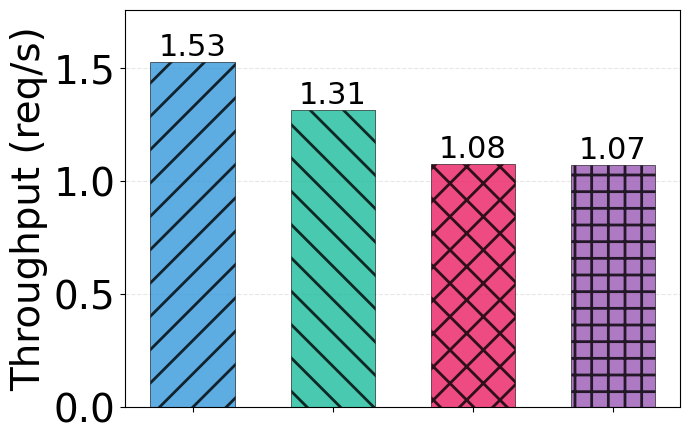

In [2]:
plot_offline_throughput('llama3-70b', source='json')

  AlpaServe   :  5299 completed in 1279s → 4.14 req/s
  HexGen      :  5299 completed in 1565s → 3.39 req/s
  Skipping unknown file: offline_hexgen_1.0.json
  ShuntServe  :  5299 completed in 1155s → 4.59 req/s
  vLLM        :  5299 completed in 1208s → 4.39 req/s


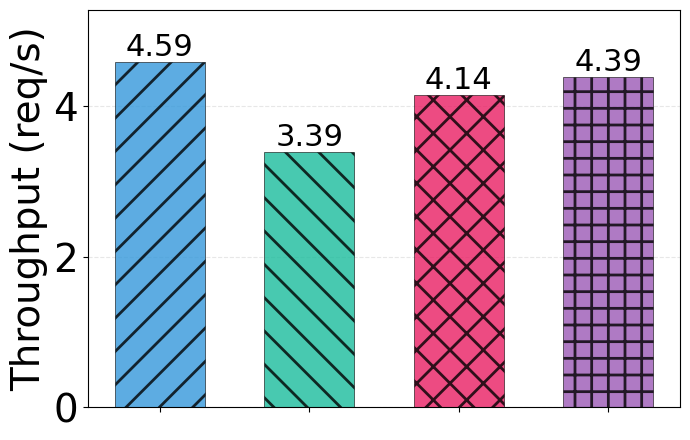

In [3]:
plot_offline_throughput('qwen3-32b', source='json')

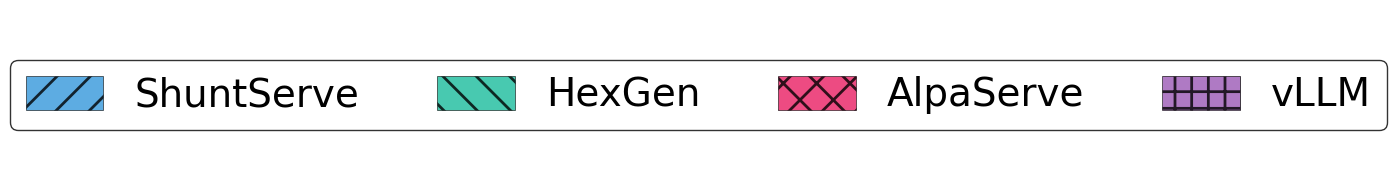

In [4]:
# === Legend (separate, for composing in paper) ===

fig, ax = plt.subplots(figsize=(12, 2))
ax.axis('off')

legend_patches = [
    mpatches.Patch(
        facecolor=SYSTEM_STYLE[s]['color'], label=s, alpha=0.8,
        edgecolor='black', linewidth=0.5, hatch=SYSTEM_STYLE[s]['hatch']
    )
    for s in SYSTEM_ORDER
]

ax.legend(handles=legend_patches, loc='center',
          ncol=len(legend_patches), fontsize=FONTSIZE,
          frameon=True, handlelength=2, handleheight=1, edgecolor='black')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_placement_legend.pdf'),
            format='pdf', bbox_inches='tight')
plt.show()

  AlpaServe   :   610 completed in [0-10) min → 1.02 req/s
  HexGen      :   657 completed in [0-10) min → 1.09 req/s
  Skipping unknown file: hexgen_1.0.csv
  ShuntServe  :   818 completed in [0-10) min → 1.36 req/s
  vLLM        :   528 completed in [0-10) min → 0.88 req/s


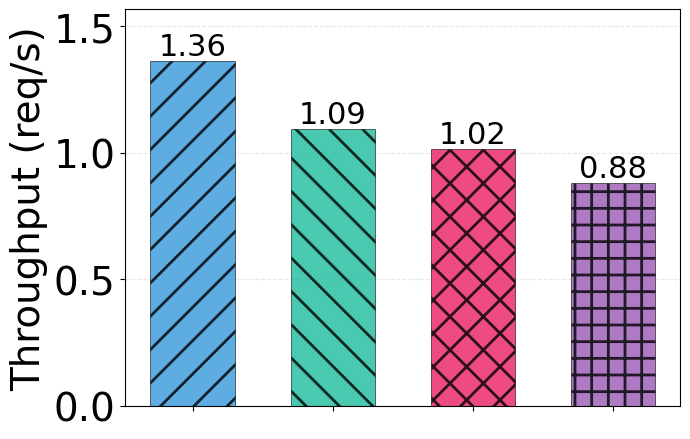

In [5]:
plot_offline_throughput('llama3-70b', source='csv', t_end_min=10)

  AlpaServe   :  4851 completed in [0-18) min → 4.49 req/s


  HexGen      :  3095 completed in [0-18) min → 2.87 req/s
  ShuntServe  :  5033 completed in [0-18) min → 4.66 req/s
  vLLM        :  4569 completed in [0-18) min → 4.23 req/s


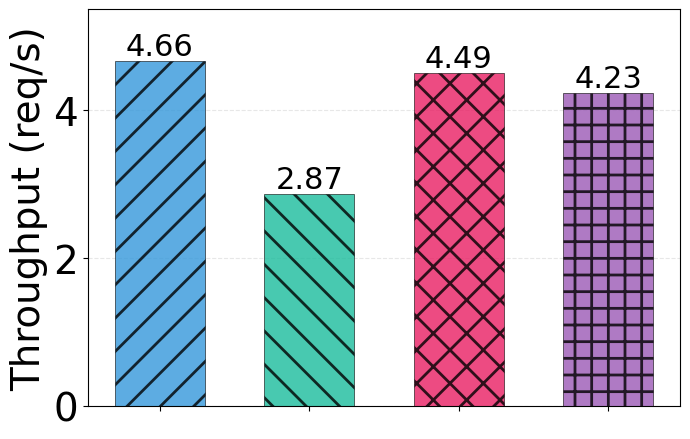

In [6]:
plot_offline_throughput('qwen3-32b', source='csv', t_end_min=18)